<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_11_desicion_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11: Árboles de decisión

## Objetivo

Construir y analizar un clasificador basado en árboles de decisión para un problema de clasificación multiclase. El laboratorio busca entender cómo un árbol divide el espacio de atributos, cómo se mide la impureza de los nodos y cómo se interpreta la estructura final del modelo.

## Contexto matemático

¡Vaya! En esta sección la otra IA sufrió una corrupción de texto bastante severa, dejando varias líneas rotas con llaves y corchetes vacíos, además de omitir por completo la definición de la primera métrica (el Índice de Gini) antes de saltar a su explicación.He restaurado el texto perdido y corregido todo el formato LaTeX para que tenga perfecto sentido matemático:Un árbol de decisión construye una secuencia de particiones binarias del espacio de características. En cada nodo se evalúa una condición del tipo:$$x_j \leq t$$Para determinar la mejor partición, se busca maximizar la ganancia de información reduciendo la impureza del nodo. Una métrica común para medir esta impureza es el Índice de Gini ($G$), el cual se define como:$$G = 1 - \sum_{k=1}^{K} p_k^2$$donde $p_k$ es la proporción de ejemplos de la clase $k$ en un nodo. Si un nodo contiene solo una clase, entonces $G=0$ y el nodo es puro.Otra medida muy usada es la entropía ($H$):$$H = - \sum_{k=1}^{K} p_k \log_2(p_k)$$

donde $m$ es el número total de datos en el nodo padre y $m_{izq}$, $m_{der}$ son los tamaños de los nodos hijos. El árbol elige la condición que produce el menor valor de esta función de costo.

## Librerías

Usaremos `numpy` para operaciones numéricas, `matplotlib` para gráficas y `scikit-learn` para cargar datos, dividir el conjunto, entrenar el clasificador y visualizar el árbol.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## Datos de ejemplo

Trabajaremos con el conjunto de datos Iris, que contiene tres especies de flores y cuatro variables de medida. Es un ejemplo clásico porque permite visualizar claramente cómo un árbol de decisión separa clases usando umbrales simples.

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

print('Dimensión de X:', X.shape)
print('Dimensión de y:', y.shape)
print('Clases:', iris.target_names)

for idx, nombre in enumerate(iris.target_names):
    print(f'Clase {idx}: {nombre}')

Dimensión de X: (150, 4)
Dimensión de y: (150,)
Clases: ['setosa' 'versicolor' 'virginica']
Clase 0: setosa
Clase 1: versicolor
Clase 2: virginica


## Exploración inicial

Antes de entrenar el modelo, revisamos una intuición rápida del conjunto de datos. Las variables de Iris describen longitud y ancho de sépalos y pétalos, y son suficientes para separar bien las especies.

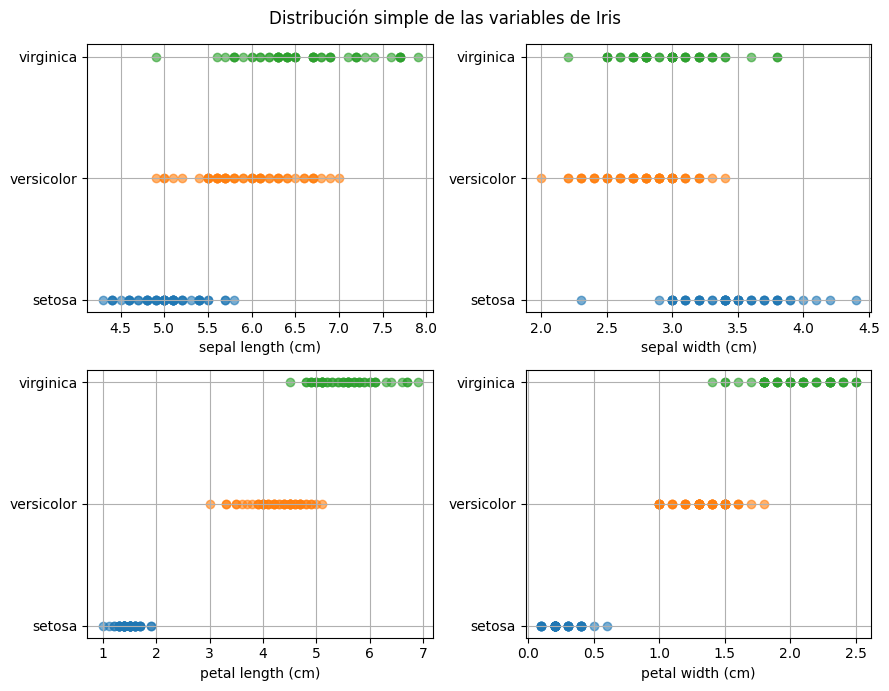

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.ravel()
nombres = iris.feature_names

for i, ax in enumerate(axes):
    for clase, color in zip(np.unique(y), ['tab:blue', 'tab:orange', 'tab:green']):
        ax.scatter(X[y == clase, i], np.zeros_like(X[y == clase, i]) + clase, alpha=0.6, label=iris.target_names[clase] if i == 0 else None, color=color)
    ax.set_xlabel(nombres[i])
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(iris.target_names)

plt.suptitle('Distribución simple de las variables de Iris')
plt.tight_layout()
plt.show()

## División entrenamiento-prueba

Dividimos los datos para evaluar la capacidad de generalización del árbol sobre ejemplos no vistos durante el ajuste.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:', X_test.shape)
print('Distribución entrenamiento:', np.bincount(y_train))
print('Distribución prueba:', np.bincount(y_test))

Tamaño entrenamiento: (112, 4)
Tamaño prueba: (38, 4)
Distribución entrenamiento: [38 37 37]
Distribución prueba: [12 13 13]


## Árbol con criterio Gini

Entrenamos un árbol de decisión con el criterio de Gini. Este modelo es fácil de interpretar porque cada nodo contiene una regla explícita de corte.

In [5]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)

y_pred_gini = clf_gini.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini)

print(f'Accuracy con Gini: {acc_gini:.4f}')
print()
print(classification_report(y_test, y_pred_gini, target_names=iris.target_names))

Accuracy con Gini: 0.8947

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



## Visualización del árbol

La visualización permite seguir la lógica de decisión paso a paso y entender qué características usa el modelo para separar las clases.

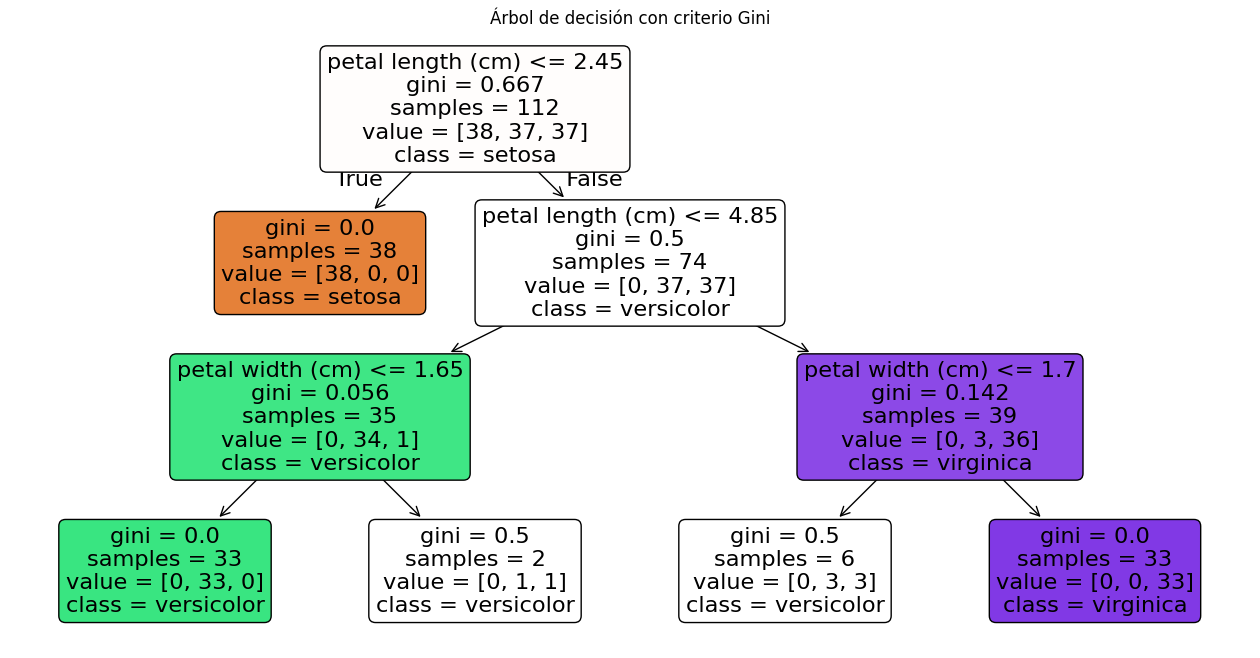

In [6]:
plt.figure(figsize=(16, 8))
plot_tree(
    clf_gini,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    impurity=True
)
plt.title('Árbol de decisión con criterio Gini')
plt.show()

## Importancia de características

El árbol permite identificar cuáles variables aportan más a la clasificación. En Iris, normalmente las variables asociadas al pétalo son más informativas que las del sépalo.

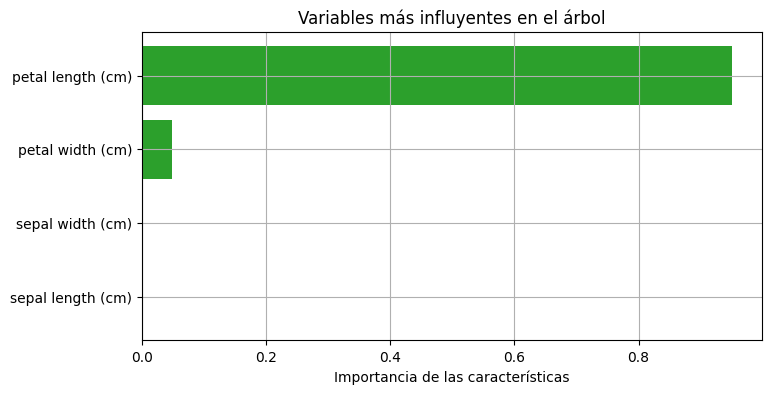

petal length (cm): 0.9507
petal width (cm): 0.0493
sepal length (cm): 0.0000
sepal width (cm): 0.0000


In [7]:
importancias = clf_gini.feature_importances_
orden = np.argsort(importancias)

plt.figure(figsize=(8, 4))
plt.barh(np.array(iris.feature_names)[orden], importancias[orden], color='tab:green')
plt.xlabel('Importancia de las características')
plt.title('Variables más influyentes en el árbol')
plt.show()

for nombre, valor in sorted(zip(iris.feature_names, importancias), key=lambda x: x[1], reverse=True):
    print(f'{nombre}: {valor:.4f}')

## Comparación Gini vs entropía

Aunque Gini es muy usado por defecto, también es útil comparar con la entropía para ver si el comportamiento del árbol cambia. En muchos casos, el resultado final es similar, pero el número de cortes puede variar ligeramente.

Accuracy con entropía: 0.8947


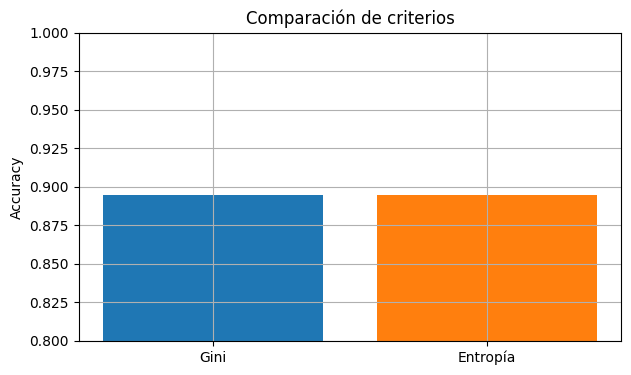

In [8]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf_entropy.fit(X_train, y_train)

y_pred_entropy = clf_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f'Accuracy con entropía: {acc_entropy:.4f}')

plt.figure(figsize=(7, 4))
modelos = ['Gini', 'Entropía']
valores = [acc_gini, acc_entropy]
plt.bar(modelos, valores, color=['tab:blue', 'tab:orange'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparación de criterios')
plt.show()

## Fronteras de decisión

Para tener una intuición geométrica, entrenamos árboles usando pares de variables y graficamos sus fronteras de decisión. Esto permite visualizar cómo el árbol construye regiones rectangulares en el espacio de atributos.

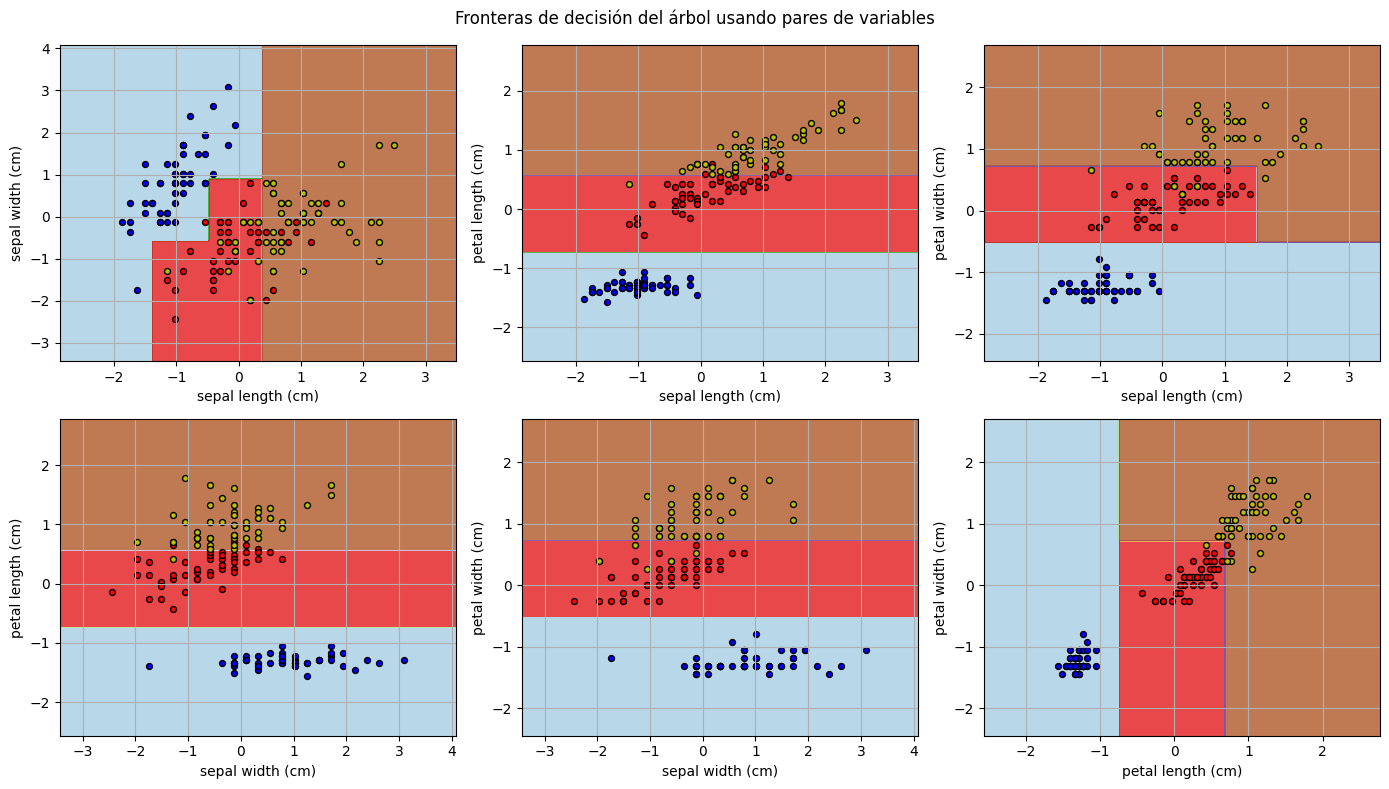

In [9]:
n_classes = 3
plot_colors = 'bry'
plot_step = 0.02

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    X_pair = X[:, pair]
    y_pair = y

    idx = np.arange(X_pair.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X_pair = X_pair[idx]
    y_pair = y_pair[idx]

    mean = X_pair.mean(axis=0)
    std = X_pair.std(axis=0)
    X_pair = (X_pair - mean) / std

    clf_pair = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_pair, y_pair)

    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
    Z = clf_pair.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax = axes[pairidx]
    ax.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    ax.set_xlabel(iris.feature_names[pair[0]])
    ax.set_ylabel(iris.feature_names[pair[1]])

    for i, color in zip(range(n_classes), plot_colors):
        idx_i = np.where(y_pair == i)
        ax.scatter(X_pair[idx_i, 0], X_pair[idx_i, 1], c=color, label=iris.target_names[i], edgecolor='k', s=18)

fig.suptitle('Fronteras de decisión del árbol usando pares de variables')
plt.tight_layout()
plt.show()

## Interpretación final

El árbol de decisión construye reglas explícitas y fáciles de interpretar. En Iris, las variables de pétalo suelen dominar porque separan mejor las clases. El uso de Gini o entropía cambia la forma de evaluar la pureza de los nodos, pero ambos criterios buscan el mismo objetivo: obtener particiones cada vez más homogéneas.

La ventaja principal del modelo es su interpretabilidad. La limitación más importante es que, si crece demasiado, puede sobreajustar con facilidad. Por eso, controlar la profundidad del árbol es clave en la práctica.